# Workshop Agent 9: The Vision-Language Agent

**Workshop:** *10 Essential AI Agents Every Engineer Must Build*  
**Book:** *30 Agents Every AI Engineer Must Build* — Imran Ahmad, Packt Publishing, 2026  
**Reference:** Chapter 11, §11.1 — Architecture of Vision-Language Agents (p.308-309), Building a Vision Question-Answering Agent (p.310-312)

---

In this session you will build a **Vision Question-Answering (VQA) agent**: an agent that loads a vision-language model and answers natural-language questions about what it sees — an image in, a natural-language answer out. You will pair a **visual encoder** with a **large language model** through an **alignment mechanism**, and guide the agent's analysis with **Chain-of-Thought prompting** so it reasons step by step before committing to an answer. Working against a synthetic workspace image generated programmatically in the notebook, you will watch the agent describe a scene, count partially occluded people, and analyze spatial relationships — the workshop's big visual moment. The notebook runs out of the box in **Simulation Mode** (mock backends, no GPU or API key required); with a CUDA GPU, a Hugging Face token, and an LLM API key, the same code runs in **Live Mode** against the real LLaVA 1.5 pipeline. You will also see the `@graceful_fallback` resilience pattern turn an invalid input into a structured, logged error instead of a crash.

### Roadmap

| Section | Content |
|---------|---------|
| §0 | Environment detection, provider banner, mode banner |
| §1.1 | Generate the synthetic test workspace image |
| §1.2 | `VisionQuestionAnsweringAgent` — CoT prompting, parsing, fallbacks |
| §1.3-§1.6 | Initialize the agent; demos: describe, count, spatial relationships |
| §1.7 | Error demo: graceful failure on invalid input |


In [ ]:
# Google Colab bootstrap — runs only on Colab, no-op everywhere else.
# Locally you are already inside the agent folder with requirements installed.
import os
import sys

if "google.colab" in sys.modules:
    AGENT_DIR = "09-vision-language-agent"
    if not os.path.exists("/content/repo"):
        os.system("git clone --depth 1 https://github.com/cloudanum/ws-10-agents /content/repo")
    os.chdir(f"/content/repo/{AGENT_DIR}")
    # Keep Colab's preinstalled scientific/kernel stack: the kernel already has
    # numpy, pandas, pydantic and ipykernel loaded, so letting pip replace them
    # (e.g. building numpy 1.26.4 from source or upgrading ipykernel) breaks the
    # running kernel with ABI errors or an OOM kill. Filter those lines out of
    # requirements and constrain the rest of the install to the installed versions.
    import re
    from importlib.metadata import PackageNotFoundError, version
    filtered = [
        line for line in open("requirements.txt")
        if not re.match(r"\s*(numpy|pandas|pydantic|jupyter|ipykernel)\b", line, re.IGNORECASE)
    ]
    with open("/tmp/colab_requirements.txt", "w") as fh:
        fh.writelines(filtered)
    pins = []
    for pkg in ("numpy", "pandas", "pydantic", "ipykernel"):
        try:
            pins.append(f"{pkg}=={version(pkg)}")
        except PackageNotFoundError:
            pass
    with open("/tmp/colab_constraints.txt", "w") as fh:
        fh.write("\n".join(pins) + "\n")
    import subprocess
    res = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "-r", "/tmp/colab_requirements.txt",
         "--constraint", "/tmp/colab_constraints.txt"],
        capture_output=True, text=True,
    )
    if res.returncode != 0:
        print("pip install failed — re-running without -q for the full resolver report:\n")
        subprocess.run(
            [sys.executable, "-m", "pip", "install",
             "-r", "/tmp/colab_requirements.txt",
             "--constraint", "/tmp/colab_constraints.txt"],
        )
        raise RuntimeError("Colab bootstrap: pip install failed (see resolver report above)")
    print(f"Colab setup complete — working directory: {os.getcwd()}")
else:
    print("Not on Colab — skipping bootstrap (local setup already in place).")

In [1]:
# ============================================================
# §0 — Environment Detection
# Ref: Technical Requirements (p.307)
# Author: Imran Ahmad
# ============================================================
# Detects GPU availability and Hugging Face token to determine
# whether to run in Simulation Mode (mock backends) or Live Mode
# (real model inference with transformers + torch).
# ============================================================

import os
import sys

# --- Load .env if present (cascading fallback) ---
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass  # python-dotenv not installed; fall through to env vars

# --- Detect environment capabilities ---
SIMULATION_REASONS = []

# Check 1: CUDA GPU availability
try:
    import torch
    HAS_CUDA = torch.cuda.is_available()
    if not HAS_CUDA:
        SIMULATION_REASONS.append("No CUDA GPU detected")
except ImportError:
    HAS_CUDA = False
    SIMULATION_REASONS.append("torch not installed")

# Check 2: Hugging Face token
HF_TOKEN = os.environ.get("HUGGINGFACE_TOKEN", "").strip()
if not HF_TOKEN or HF_TOKEN == "your_hugging_face_token_here":
    HAS_TOKEN = False
    SIMULATION_REASONS.append("No valid HUGGINGFACE_TOKEN in environment")
else:
    HAS_TOKEN = True

# --- Final mode decision ---
SIMULATION_MODE = not (HAS_CUDA and HAS_TOKEN)


In [2]:
# Multi-provider LLM support (OpenAI / Anthropic / Google Gemini)
# Set LLM_PROVIDER in .env to choose: openai | anthropic | google | auto
# Auto-detection uses the first available key.
# See supporting/llm_provider.py for details.

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, '..')

try:
    from supporting.llm_provider import detect_provider, get_llm, PROVIDER_MODELS, print_provider_banner
    _PROVIDER, _PROVIDER_KEY, _PROVIDER_MODE = detect_provider()
    print_provider_banner(_PROVIDER, _PROVIDER_MODE)
except ImportError:
    print('[INFO] supporting/llm_provider.py not found — using default OpenAI path')
    _PROVIDER, _PROVIDER_KEY, _PROVIDER_MODE = 'openai', os.getenv('OPENAI_API_KEY'), 'LIVE' if os.getenv('OPENAI_API_KEY') else 'SIMULATION'



   SIMULATION MODE ACTIVE
   Using MockLLM — no API key required



In [3]:
# ============================================================
# §0 — Mode Banner
# Ref: Technical Requirements (p.307)
# Author: Imran Ahmad
# ============================================================

from agent_logger import AgentLogger

if SIMULATION_MODE:
    reasons = "; ".join(SIMULATION_REASONS) if SIMULATION_REASONS else "Forced by configuration"
    AgentLogger.info(f"Simulation Mode active. Reasons: {reasons}")
    AgentLogger.info(
        "All agents will use mock backends from mock_backends.py. "
        "No GPU or API token required."
    )
else:
    AgentLogger.success("Live Mode active. CUDA GPU and Hugging Face token detected.")
    AgentLogger.info("Agents will use real model inference via transformers + torch.")

AgentLogger.info(f"Python {sys.version.split()[0]} | CUDA: {HAS_CUDA} | HF Token: {HAS_TOKEN}")


[INFO] Simulation Mode active. Reasons: torch not installed; No valid HUGGINGFACE_TOKEN in environment
[INFO] All agents will use mock backends from mock_backends.py. No GPU or API token required.
[INFO] Python 3.14.5 | CUDA: False | HF Token: False


---

# Part 1: Vision-Language Agents

> *Ref: Architecture of Vision-Language Agents (p.308-309), Building a Vision Question-Answering Agent (p.310-312)*

Vision-Language agents pair a **visual encoder** (typically a Vision Transformer / ViT) with a **large language model** through an **alignment mechanism** that projects visual embeddings into the language model's token space. This three-component architecture enables the agent to reason jointly over image content and natural language inputs.

The key architectural insight: unlike systems that process textual descriptions of images (where information loss is inevitable), Vision-Language agents ingest **raw visual data** alongside natural language instructions. This direct access to pixel-level information enables capabilities that would otherwise be impossible — counting partially occluded objects, recognizing subtle emotional expressions, or identifying spatial relationships that resist verbal description.

### Figure 11.1 — Vision-Language Agent Architecture

The diagram below shows the three foundational components working in concert:


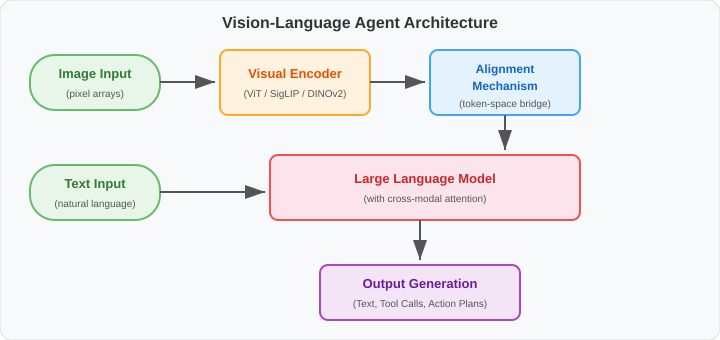

In [4]:
# ============================================================
# Figure 11.1 — Vision-Language Agent Architecture (SVG)
# Ref: Architecture of Vision-Language Agents (p.308-309)
# ============================================================

from IPython.display import SVG, display, HTML

vl_architecture_svg = """
<svg viewBox="0 0 720 340" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs>
    <marker id="arrowhead" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0, 10 3.5, 0 7" fill="#555"/></marker>
  </defs>
  <!-- Background -->
  <rect width="720" height="340" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <text x="360" y="28" text-anchor="middle" font-size="16" font-weight="bold" fill="#333">Vision-Language Agent Architecture</text>
  <!-- Image Input -->
  <rect x="30" y="55" width="130" height="55" rx="25" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2"/>
  <text x="95" y="78" text-anchor="middle" font-size="13" font-weight="bold" fill="#2e7d32">Image Input</text>
  <text x="95" y="97" text-anchor="middle" font-size="10" fill="#555">(pixel arrays)</text>
  <!-- Text Input -->
  <rect x="30" y="165" width="130" height="55" rx="25" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2"/>
  <text x="95" y="188" text-anchor="middle" font-size="13" font-weight="bold" fill="#2e7d32">Text Input</text>
  <text x="95" y="207" text-anchor="middle" font-size="10" fill="#555">(natural language)</text>
  <!-- Visual Encoder -->
  <rect x="220" y="50" width="150" height="65" rx="8" fill="#fff3e0" stroke="#ffa726" stroke-width="2"/>
  <text x="295" y="78" text-anchor="middle" font-size="13" font-weight="bold" fill="#e65100">Visual Encoder</text>
  <text x="295" y="97" text-anchor="middle" font-size="10" fill="#555">(ViT / SigLIP / DINOv2)</text>
  <!-- Alignment Mechanism -->
  <rect x="430" y="50" width="150" height="65" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
  <text x="505" y="73" text-anchor="middle" font-size="12" font-weight="bold" fill="#1565c0">Alignment</text>
  <text x="505" y="90" text-anchor="middle" font-size="12" font-weight="bold" fill="#1565c0">Mechanism</text>
  <text x="505" y="107" text-anchor="middle" font-size="10" fill="#555">(token-space bridge)</text>
  <!-- LLM -->
  <rect x="270" y="155" width="310" height="65" rx="8" fill="#fce4ec" stroke="#ef5350" stroke-width="2"/>
  <text x="425" y="183" text-anchor="middle" font-size="13" font-weight="bold" fill="#c62828">Large Language Model</text>
  <text x="425" y="202" text-anchor="middle" font-size="10" fill="#555">(with cross-modal attention)</text>
  <!-- Output -->
  <rect x="320" y="265" width="200" height="55" rx="8" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
  <text x="420" y="288" text-anchor="middle" font-size="13" font-weight="bold" fill="#6a1b9a">Output Generation</text>
  <text x="420" y="307" text-anchor="middle" font-size="10" fill="#555">(Text, Tool Calls, Action Plans)</text>
  <!-- Arrows -->
  <line x1="160" y1="82" x2="215" y2="82" stroke="#555" stroke-width="2" marker-end="url(#arrowhead)"/>
  <line x1="370" y1="82" x2="425" y2="82" stroke="#555" stroke-width="2" marker-end="url(#arrowhead)"/>
  <line x1="505" y1="115" x2="505" y2="150" stroke="#555" stroke-width="2" marker-end="url(#arrowhead)"/>
  <line x1="160" y1="192" x2="265" y2="192" stroke="#555" stroke-width="2" marker-end="url(#arrowhead)"/>
  <line x1="420" y1="220" x2="420" y2="260" stroke="#555" stroke-width="2" marker-end="url(#arrowhead)"/>
</svg>
"""
display(SVG(vl_architecture_svg))


> **📝 Note — SigLIP vs. DINOv2 (p.309)**  
> **SigLIP** is generally preferred for tasks requiring language-aligned retrieval, as it is trained with a contrastive image-text objective that tightly couples visual and linguistic representations.  
> **DINOv2**, by contrast, uses self-supervised learning without text supervision, producing spatially rich features that excel in dense prediction tasks such as depth estimation and semantic segmentation.  
> The choice of encoder is therefore the first and most consequential architectural decision in a Vision-Language system.


[SUCCESS] Test image saved to assets/sample_workspace.png (640x480)


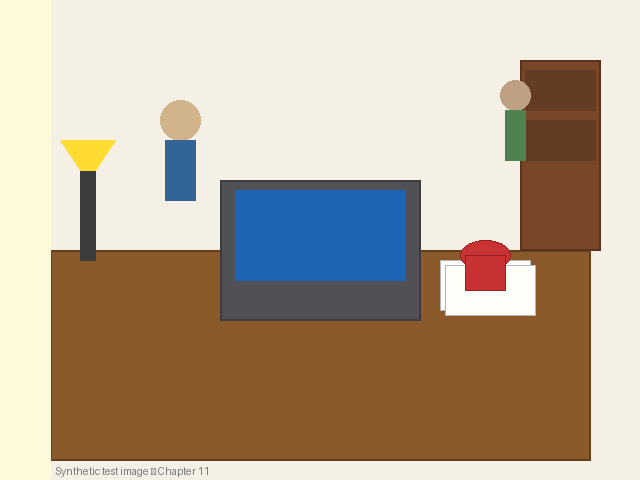

In [5]:
# ============================================================
# §1.1 — Generate Test Image (Programmatic)
# Ref: Building a Vision Question-Answering Agent (p.310)
# Author: Imran Ahmad
# ============================================================
# Creates a synthetic workspace image for the Vision agent demos.
# No external downloads required.
# ============================================================

import numpy as np
from PIL import Image, ImageDraw, ImageFont
import os

def create_test_workspace_image(path: str = "assets/sample_workspace.png") -> Image.Image:
    """
    Generate a synthetic workspace image with identifiable objects
    for the VisionQuestionAnsweringAgent demos.

    Objects drawn: desk surface, laptop, coffee cup, papers, desk lamp,
    two stylized person silhouettes (one partially occluded).

    Ref: Building a Vision Question-Answering Agent (p.310-311)
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    img = Image.new("RGB", (640, 480), color=(245, 240, 230))  # Warm beige background
    draw = ImageDraw.Draw(img)

    # Desk surface (brown rectangle)
    draw.rectangle([50, 250, 590, 460], fill=(139, 90, 43), outline=(100, 65, 30), width=2)

    # Laptop (gray rectangle with blue screen)
    draw.rectangle([220, 180, 420, 320], fill=(80, 80, 85), outline=(60, 60, 65), width=2)
    draw.rectangle([235, 190, 405, 280], fill=(30, 100, 180))  # Screen

    # Coffee cup (right side, on papers — "precariously balanced")
    # Papers first
    draw.rectangle([440, 260, 530, 310], fill=(255, 255, 255), outline=(180, 180, 180))
    draw.rectangle([445, 265, 535, 315], fill=(255, 255, 250), outline=(180, 180, 180))
    # Cup
    draw.ellipse([460, 240, 510, 270], fill=(200, 50, 50), outline=(150, 30, 30))
    draw.rectangle([465, 255, 505, 290], fill=(200, 50, 50), outline=(150, 30, 30))

    # Desk lamp (upper left)
    draw.rectangle([80, 160, 95, 260], fill=(60, 60, 60))  # Pole
    draw.polygon([(60, 140), (115, 140), (95, 170), (80, 170)], fill=(255, 220, 50))  # Shade

    # Person 1 (seated, center-left)
    draw.ellipse([160, 100, 200, 140], fill=(210, 180, 140))  # Head
    draw.rectangle([165, 140, 195, 200], fill=(50, 100, 150))  # Torso

    # Person 2 (partially occluded by bookshelf, right background)
    # Bookshelf
    draw.rectangle([520, 60, 600, 250], fill=(120, 70, 40), outline=(90, 50, 30), width=2)
    draw.rectangle([525, 70, 595, 110], fill=(100, 60, 35))  # Shelf
    draw.rectangle([525, 120, 595, 160], fill=(100, 60, 35))  # Shelf
    # Person behind bookshelf (partially visible)
    draw.ellipse([500, 80, 530, 110], fill=(190, 160, 130))  # Head
    draw.rectangle([505, 110, 525, 160], fill=(80, 130, 80))  # Torso (partially hidden)

    # Window light indicator (left side, yellowish glow)
    draw.rectangle([0, 0, 50, 480], fill=(255, 250, 220))

    # Label for educational clarity
    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 12)
    except (OSError, IOError):
        font = ImageFont.load_default()
    draw.text((55, 465), "Synthetic test image — Chapter 11", fill=(120, 120, 120), font=font)

    img.save(path)
    AgentLogger.success(f"Test image saved to {path} ({img.size[0]}x{img.size[1]})")
    return img

test_image = create_test_workspace_image()
test_image


In [6]:
# ============================================================
# §1.2 — VisionQuestionAnsweringAgent
# Ref: Building a Vision Question-Answering Agent (p.310-312)
# Author: Imran Ahmad
# ============================================================
# Implements the VQA agent with Chain-of-Thought prompting.
# Uses MockVLM + MockProcessor in Simulation Mode, or the real
# LLaVA 1.5 pipeline in Live Mode.
#
# Architecture (Ref: Architecture of Vision-Language Agents, p.308-309):
#   Image Input → Visual Encoder (ViT) → Alignment Mechanism →
#   Large Language Model (with cross-modal attention) → Output
# ============================================================

from agent_logger import AgentLogger, graceful_fallback

class VisionQuestionAnsweringAgent:
    """
    A vision-language agent capable of answering questions about images.
    Implements Chain-of-Thought reasoning for improved accuracy.

    In Simulation Mode, uses MockProcessor and MockVLM from
    mock_backends.py. In Live Mode, uses the real LLaVA 1.5
    pipeline from Hugging Face transformers.

    Ref: Building a Vision Question-Answering Agent (p.310-312)
    """

    def __init__(self, model_id: str = "llava-hf/llava-1.5-7b-hf"):
        """
        Initialize the agent with a pre-trained Vision-Language Model.

        Args:
            model_id: HuggingFace model identifier. LLaVA 1.5 provides
                      a good balance of capability and resource requirements.

        Ref: Initialization and Model Loading (p.310-311)
        """
        AgentLogger.info(f"Initializing Vision-Language Agent (model: {model_id})...")

        if SIMULATION_MODE:
            from mock_backends import MockProcessor, MockVLM
            self.processor = MockProcessor.from_pretrained(model_id)
            self.model = MockVLM.from_pretrained(model_id)
            AgentLogger.success("Agent ready (Simulation Mode)")
        else:
            import torch
            from transformers import AutoProcessor, LlavaForConditionalGeneration

            self.processor = AutoProcessor.from_pretrained(model_id)
            # Load with mixed precision (float16) for efficiency.
            # device_map="auto" distributes across available GPUs and
            # falls back to CPU when necessary.
            # Ref: Initialization and Model Loading (p.310-311)
            self.model = LlavaForConditionalGeneration.from_pretrained(
                model_id,
                torch_dtype=torch.float16,
                low_cpu_mem_usage=True,
                device_map="auto",
            )
            AgentLogger.success("Agent ready (Live Mode)")

        self.conversation_history = []

    @graceful_fallback(max_retries=2, base_delay=0.5)
    def answer_question(
        self,
        image: "Image.Image",
        question: str,
        use_chain_of_thought: bool = True,
    ) -> dict:
        """
        Answer a question about the provided image.

        Args:
            image: PIL Image object to analyze.
            question: Natural language question about the image.
            use_chain_of_thought: Whether to use step-by-step reasoning.

        Returns:
            Dictionary containing 'answer' and optionally 'reasoning'.

        Ref: Building a Vision Question-Answering Agent (p.310-312)
        """
        AgentLogger.info(f"answer_question called: '{question[:60]}...'")

        # Validate input
        if image is None:
            raise TypeError("NoneType image received — cannot process a null image input")

        # Construct prompt based on reasoning strategy
        if use_chain_of_thought:
            cot_instruction = self._build_cot_prompt(question)
            prompt = f"USER: <image>\n{cot_instruction}\nASSISTANT:"
        else:
            prompt = f"USER: <image>\n{question}\nASSISTANT:"

        # Process inputs: tokenize text and preprocess image
        inputs = self.processor(
            text=prompt,
            images=image,
            return_tensors="pt",
        ).to(self.model.device)

        # Generate response with deterministic decoding
        if SIMULATION_MODE:
            outputs = self.model.generate(**inputs, max_new_tokens=512)
        else:
            import torch
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=512,
                    do_sample=False,  # Greedy decoding for reproducibility
                )

        # Decode and parse
        full_response = self.processor.decode(outputs[0], skip_special_tokens=True)
        response_text = full_response.split("ASSISTANT:")[-1].strip()
        result = self._parse_response(response_text, use_chain_of_thought)

        AgentLogger.success(
            f"answer_question completed. "
            f"{'CoT reasoning extracted.' if 'reasoning' in result else 'Direct answer.'}"
        )
        return result

    def _build_cot_prompt(self, question: str) -> str:
        """
        Construct a Chain-of-Thought prompt for visual reasoning.

        The structured format guides the model through systematic
        analysis rather than pattern-matching to likely answers.

        Ref: Chain-of-Thought prompting pattern (p.315-316)
        """
        return (
            f'Analyze the image carefully and answer the following question: '
            f'"{question}"\n\n'
            f'Please think step by step:\n'
            f'1. First, identify the relevant objects or features visible in the image.\n'
            f'2. Then, examine the specific details needed to answer the question.\n'
            f'3. Finally, provide your answer based on the visual evidence.\n\n'
            f'Format your response as:\n'
            f'Reasoning: [Your step-by-step analysis]\n'
            f'Therefore, the answer is: [Your final answer]'
        )

    def _parse_response(self, response: str, has_reasoning: bool) -> dict:
        """
        Extract structured output from model response.

        When CoT is enabled, extracts the reasoning trace separately
        from the final answer. This separation enables explainability
        and supports debugging.

        Ref: Parsing and Structured Output (p.316-317)
        """
        if has_reasoning and "Therefore, the answer is:" in response:
            parts = response.split("Therefore, the answer is:")
            return {
                "reasoning": parts[0].replace("Reasoning:", "").strip(),
                "answer": parts[1].strip().rstrip("."),
            }
        return {"answer": response.strip()}

AgentLogger.success("VisionQuestionAnsweringAgent class defined.")


[SUCCESS] VisionQuestionAnsweringAgent class defined.


In [7]:
# ============================================================
# §1.3 — Initialize the Vision-Language Agent
# Ref: Building a Vision Question-Answering Agent (p.310-311)
# Author: Imran Ahmad
# ============================================================

vqa_agent = VisionQuestionAnsweringAgent()


[INFO] Initializing Vision-Language Agent (model: llava-hf/llava-1.5-7b-hf)...
[SUCCESS] Agent ready (Simulation Mode)


In [8]:
# ============================================================
# §1.4 — Demo: Describe Workspace
# Ref: Building a Vision Question-Answering Agent (p.310-312)
# Author: Imran Ahmad
# ============================================================
# Scenario: Ask the agent to describe the synthetic workspace image.
# Tests the CoT reasoning pipeline end-to-end.
# ============================================================

result_describe = vqa_agent.answer_question(
    image=test_image,
    question="Describe this workspace in detail.",
    use_chain_of_thought=True,
)

print("\n--- Vision Agent: Describe Workspace ---")
if "reasoning" in result_describe:
    print(f"Reasoning: {result_describe['reasoning'][:200]}...")
print(f"Answer: {result_describe['answer']}")


[INFO] answer_question called: 'Describe this workspace in detail....'
[SUCCESS] answer_question completed. CoT reasoning extracted.

--- Vision Agent: Describe Workspace ---
Reasoning: The image shows an indoor workspace. I can identify a desk with a laptop, scattered papers, a coffee cup positioned near the edge, and an adjustable desk lamp. The lighting suggests daytime with natur...
Answer: This is a cluttered workspace containing a laptop, papers, a coffee cup precariously balanced on a stack of documents, and a desk lamp. Natural light enters from the left


In [9]:
# ============================================================
# §1.5 — Demo: Count People
# Ref: Building a Vision Question-Answering Agent (p.310-312)
# Author: Imran Ahmad
# ============================================================
# Scenario: Count partially occluded objects — a task that
# demonstrates why direct visual access matters versus textual
# descriptions (Ref: Architecture of VL Agents, p.309).
# ============================================================

result_count = vqa_agent.answer_question(
    image=test_image,
    question="How many people are visible in this image? Count carefully.",
    use_chain_of_thought=True,
)

print("\n--- Vision Agent: Count People ---")
if "reasoning" in result_count:
    print(f"Reasoning: {result_count['reasoning'][:200]}...")
print(f"Answer: {result_count['answer']}")


[INFO] answer_question called: 'How many people are visible in this image? Count carefully....'
[SUCCESS] answer_question completed. CoT reasoning extracted.

--- Vision Agent: Count People ---
Reasoning: I will scan the image systematically from left to right. I can see one person seated at the desk and a second person partially occluded by the bookshelf in the background. There are no other figures v...
Answer: 2 people are visible in the image


In [10]:
# ============================================================
# §1.6 — Demo: Spatial Relationships
# Ref: Integration Patterns and Production Considerations (p.311-312)
# Author: Imran Ahmad
# ============================================================
# Scenario: Analyze spatial layout — demonstrates cross-modal
# attention grounding linguistic reasoning in visual evidence.
# ============================================================

result_spatial = vqa_agent.answer_question(
    image=test_image,
    question="Describe the spatial relationship between the laptop, coffee cup, and desk lamp.",
    use_chain_of_thought=True,
)

print("\n--- Vision Agent: Spatial Relationships ---")
if "reasoning" in result_spatial:
    print(f"Reasoning: {result_spatial['reasoning'][:200]}...")
print(f"Answer: {result_spatial['answer']}")


[INFO] answer_question called: 'Describe the spatial relationship between the laptop, coffee...'
[SUCCESS] answer_question completed. CoT reasoning extracted.

--- Vision Agent: Spatial Relationships ---
Reasoning: Analyzing spatial layout — the laptop is centered on the desk. The coffee cup is to the right, approximately 15cm from the laptop edge. Papers are stacked beneath the cup. The desk lamp is positioned ...
Answer: The laptop occupies the center of the desk, with the coffee cup to its right resting on a paper stack, and the desk lamp at the upper-left corner


### Integration Patterns and Production Considerations

> *Ref: Integration Patterns and Production Considerations (p.311-312)*

The `VisionQuestionAnsweringAgent` above uses a **direct integration** pattern where the model is loaded locally. In production, three architectural patterns are common:

- **Adapter-based integration:** Lightweight projection layers between frozen encoder and frozen LLM. Less than 1% of parameters trained. Efficient but limited on out-of-distribution visual concepts.
- **Cross-attention integration:** Dedicated attention layers allowing language tokens to attend specifically to visual encoder outputs. Models like **Flamingo** exemplify this pattern, demonstrating strong few-shot visual learning capabilities.
- **Early fusion:** Concatenates visual and textual tokens into a single unified sequence. Maximizes cross-modal reasoning potential but increases sequence length and computational overhead.

> **📝 Note — Latency Management Techniques (p.312)**  
> When deploying Vision-Language agents, latency is a critical bottleneck. Practical techniques include:  
> - **Image resolution scaling:** Reducing from 1024×1024 to 336×336 can cut visual tokens by 90%  
> - **Patch pruning:** Dynamically removing uninformative patches (uniform regions, backgrounds)  
> - **Speculative decoding:** Smaller models verified by larger models  
> - **Caching:** Storing visual embeddings for frequently accessed images

> **📝 Note — Accuracy Validation (p.312)**  
> Robust production systems implement accuracy validation, cross-checking agent outputs against deterministic computer vision models. If a VL agent claims an image contains three people, a dedicated object detector can verify this count. Such validation layers are essential for mitigating hallucination risks.


In [11]:
# ============================================================
# §1.7 — Error Demo: Graceful Failure on Invalid Input
# Ref: Building a Vision Question-Answering Agent (p.310-312)
# Author: Imran Ahmad
# ============================================================
# Demonstrates the @graceful_fallback decorator in action.
# Passing None as the image triggers a TypeError, which the
# decorator catches, logs in RED, retries, and returns a
# structured fallback dictionary.
# ============================================================

AgentLogger.info("Demonstrating error handling with None image input...")

result_error = vqa_agent.answer_question(
    image=None,
    question="Describe this image.",
    use_chain_of_thought=True,
)

print("\n--- Vision Agent: Error Demo ---")
print(f"Error response: {result_error}")
assert result_error.get("error") is True, "Expected fallback error response"
AgentLogger.success("Error handling demo complete — @graceful_fallback worked as expected.")


[INFO] Demonstrating error handling with None image input...
[INFO] answer_question called: 'Describe this image....'
[ERROR] answer_question attempt 1/2 failed: TypeError: NoneType image received — cannot process a null image input


[INFO] answer_question called: 'Describe this image....'
[ERROR] answer_question attempt 2/2 failed: TypeError: NoneType image received — cannot process a null image input
[ERROR] answer_question failed after 2 attempts. Returning fallback response.

--- Vision Agent: Error Demo ---
Error response: {'error': True, 'function': 'answer_question', 'exception': 'NoneType image received — cannot process a null image input', 'exception_type': 'TypeError', 'message': 'answer_question failed: TypeError. Falling back.'}
[SUCCESS] Error handling demo complete — @graceful_fallback worked as expected.


---

## Summary

- **Three-component architecture** — a visual encoder (ViT / SigLIP / DINOv2), an alignment mechanism, and an LLM with cross-modal attention let the agent reason jointly over pixels and language.
- **Direct visual access matters** — ingesting raw pixel arrays enables capabilities impossible from textual descriptions alone, such as counting partially occluded objects.
- **Chain-of-Thought prompting** — a structured "Reasoning → Therefore, the answer is" format yields systematic analysis and a separable, inspectable reasoning trace.
- **Production patterns** — adapter-based, cross-attention, and early-fusion integration trade parameter efficiency against cross-modal reasoning power; latency and accuracy validation require deliberate engineering.
- **Resilience by design** — the `@graceful_fallback` decorator converts inference failures into structured error responses with retry and exponential backoff.

**Next step:** Chapter 11 continues with the Audio Processing Agents (§11.2) and Physical World Sensing Agents (§11.3) in the book — *30 Agents Every AI Engineer Must Build*, Packt Publishing, 2026.
